## Install Libraries and Imports

In [6]:
!pip install -q transformers datasets accelerate scikit-learn pandas seaborn matplotlib torch


In [7]:
import os
import re
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

print("✅ All libraries installed and imported successfully.")

✅ All libraries installed and imported successfully.


In [8]:
def generate_repo_labels(df):
    """
    Generate labels based on topics with hierarchical priority and confidence.
    Priority: AI > Data Science > Mobile > DevOps > Web
    """
    HIERARCHY = ['AI', 'Data Science', 'Mobile', 'DevOps', 'Web']
    FULL_NAMES = {
        'AI': 'AI / Machine Learning',
        'Data Science': 'Data Science',
        'Mobile': 'Mobile Applications',
        'DevOps': 'DevOps',
        'Web': 'Web Development'
    }
    KEYWORDS = {
        'AI': ['machine-learning', 'deep-learning', 'neural-network', 'tensorflow',
               'pytorch', 'llm', 'transformer', 'artificial-intelligence', 'nlp',
               'computer-vision', 'keras', 'scikit-learn'],
        'Data Science': ['data-science', 'pandas', 'numpy', 'data-analysis', 'visualization',
                         'matplotlib', 'jupyter', 'data-mining', 'big-data', 'sql'],
        'Mobile': ['android', 'ios', 'mobile', 'flutter', 'react-native', 'swift',
                   'kotlin', 'xamarin', 'mobile-app'],
        'DevOps': ['docker', 'kubernetes', 'ci-cd', 'devops', 'aws', 'azure', 'gcp',
                   'terraform', 'ansible', 'jenkins', 'cloud', 'infrastructure'],
        'Web': ['react', 'frontend', 'backend', 'web', 'javascript', 'vue', 'angular',
                'nodejs', 'express', 'django', 'flask', 'html', 'css', 'rest-api', 'graphql']
    }

    def classify_row(row):
        topics = row.get('topics_list', [])
        if isinstance(topics, str):
            try:
                import ast
                topics = ast.literal_eval(topics)
            except:
                topics = [t.strip() for t in topics.replace('|', ',').split(',') if t.strip()]
        topics_lower = [t.lower() for t in topics]

        matched = {}
        for cat, kws in KEYWORDS.items():
            count = sum(1 for kw in kws if kw.lower() in topics_lower)
            if count > 0:
                matched[cat] = count
        if not matched:
            return None, 0.0, "No matching topics found"

        for priority_cat in HIERARCHY:
            if priority_cat in matched:
                confidence = min(0.95, (matched[priority_cat] / len(KEYWORDS[priority_cat])) * 2 + 0.5)
                reason = f"Matched {matched[priority_cat]} keywords for {FULL_NAMES[priority_cat]}"
                return FULL_NAMES[priority_cat], round(confidence, 2), reason
        return None, 0.0, "Fallback: No priority match"

    results = df.apply(classify_row, axis=1)
    df['label'] = [r[0] for r in results]
    df['confidence'] = [r[1] for r in results]
    df['reason'] = [r[2] for r in results]
    return df[['name', 'description', 'readme', 'topics_list', 'label', 'confidence', 'reason']]

# Load your CSV (update path if needed)
df_raw = pd.read_csv('/content/cleaned_data.csv')
df_labeled = generate_repo_labels(df_raw)
df_labeled.dropna(subset=['label'], inplace=True)
print(df_labeled.head())

                name                                        description  \
0         tensorflow  An Open Source Machine Learning Framework for ...   
1       prompts.chat  f.k.a. Awesome ChatGPT Prompts. Share, discove...   
2       transformers  🤗 Transformers: the model-definition framework...   
3            pytorch  Tensors and Dynamic neural networks in Python ...   
4  LLMs-from-scratch  Implement a ChatGPT-like LLM in PyTorch from s...   

                                              readme  \
0  <div align="center">\n  <img src="https://www....   
1  <h1 align="center">\n  <a href="https://prompt...   
2  <!---\nCopyright 2020 The HuggingFace Team. Al...   
3  ![PyTorch Logo](https://github.com/pytorch/pyt...   
4  # Build a Large Language Model (From Scratch)\...   

                                         topics_list                  label  \
0  ['deep-learning', 'deep-neural-networks', 'dis...  AI / Machine Learning   
1  ['ai', 'artificial-intelligence', 'awesome-lis...  

/tmp/ipykernel_3357/2899133244.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_labeled.dropna(subset=['label'], inplace=True)


In [9]:
def clean_and_tokenize(df, max_length=512):
    """
    Clean text, combine description + README, tokenize using DistilBERT,
    then split into Train/Val/Test (70/15/15).
    """
    def clean_text(text):
        if not isinstance(text, str):
            return ""
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'!\[.*?\]\(.*?\)', '', text)
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'```[\s\S]*?```', ' ', text)
        text = re.sub(r'[^\w\s.,!?;:\-\']', ' ', text)
        return re.sub(r'\s+', ' ', text).strip()

    # Combine description + README
    df['clean_text'] = df['description'].fillna('') + " [SEP] " + df['readme'].fillna('')
    df['clean_text'] = df['clean_text'].apply(clean_text)

    # Map labels to IDs (5 classes)
    label2id = {
        'AI / Machine Learning': 0,
        'Data Science': 1,
        'Mobile Applications': 2,
        'DevOps': 3,
        'Web Development': 4
    }
    id2label = {v: k for k, v in label2id.items()}
    df['label_id'] = df['label'].map(label2id)

    # Train/val/test split
    train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

    # Tokenizer
    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

    def tokenize_function(examples):
        return tokenizer(
            examples['clean_text'],
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )

    def create_hf_dataset(dataframe):
        dataset = Dataset.from_pandas(dataframe[['clean_text', 'label_id']])
        tokenized = dataset.map(tokenize_function, batched=True, remove_columns=['clean_text'])
        return tokenized.rename_column('label_id', 'labels')

    train_dataset = create_hf_dataset(train_df)
    val_dataset = create_hf_dataset(val_df)
    test_dataset = create_hf_dataset(test_df)

    print(f"✅ Split complete: Train={len(train_dataset)} | Val={len(val_dataset)} | Test={len(test_dataset)}")
    return train_dataset, val_dataset, test_dataset, label2id, id2label, tokenizer

# Run it
train_ds, val_ds, test_ds, label2id, id2label, tokenizer = clean_and_tokenize(df_labeled)

/tmp/ipykernel_3357/1448004776.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_text'] = df['description'].fillna('') + " [SEP] " + df['readme'].fillna('')
/tmp/ipykernel_3357/1448004776.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_text'] = df['clean_text'].apply(clean_text)
/tmp/ipykernel_3357/1448004776.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/325 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

✅ Split complete: Train=325 | Val=70 | Test=70


In [10]:
def setup_model_and_training_args(label2id, id2label, train_dataset, val_dataset):
    # Load pretrained model
    model = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=5,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    # Compute metrics (macro F1)
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        macro_f1 = f1_score(labels, predictions, average='macro', zero_division=0)
        return {"f1_macro": macro_f1}

    training_args = TrainingArguments(
        output_dir="./distilbert_github_results",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        fp16=True,
        logging_steps=10,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    print("✅ Model and Trainer ready.")
    return trainer

# Create trainer
trainer = setup_model_and_training_args(label2id, id2label, train_ds, val_ds)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model and Trainer ready.


🚀 Starting training...


Epoch,Training Loss,Validation Loss,F1 Macro
1,1.170334,1.215608,0.138318
2,1.091452,0.921041,0.329646
3,0.776347,0.719469,0.552153
4,0.626494,0.582479,0.630549
5,0.371844,0.538642,0.655000
6,0.295357,0.541733,0.631748
7,0.144734,0.508341,0.742995
8,0.105260,0.510260,0.773974
9,0.084446,0.533138,0.762471
10,0.064032,0.530568,0.762471


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


✅ Training complete.

📊 Final evaluation on Test Set...



📋 CLASSIFICATION REPORT
                       precision    recall  f1-score   support

AI / Machine Learning       0.86      1.00      0.93        37
         Data Science       0.00      0.00      0.00         3
  Mobile Applications       0.88      0.88      0.88         8
               DevOps       0.87      0.76      0.81        17
      Web Development       1.00      0.80      0.89         5

             accuracy                           0.87        70
            macro avg       0.72      0.69      0.70        70
         weighted avg       0.84      0.87      0.85        70

🎯 Final Macro F1-Score on Test Set: 0.7003


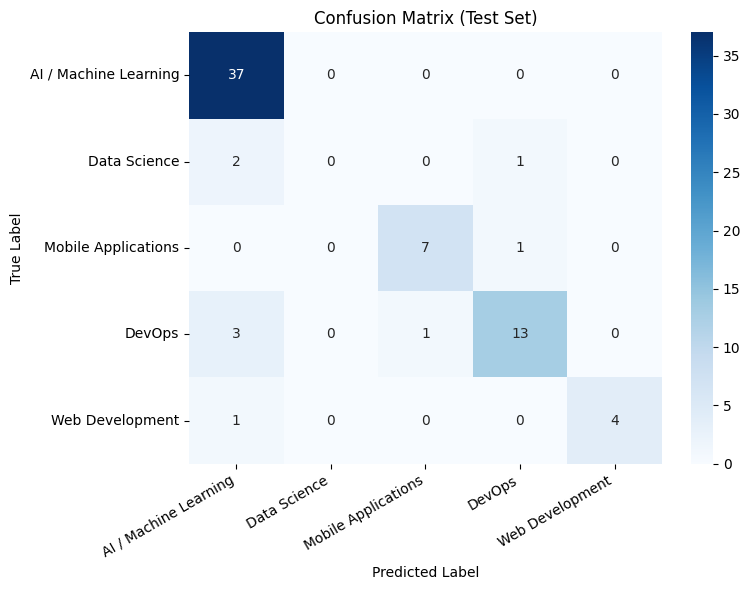

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Best model saved to: ./best_distilbert_github_model


In [11]:
def train_and_evaluate(trainer, test_dataset, id2label):
    print("🚀 Starting training...")
    train_output = trainer.train()
    print("✅ Training complete.")

    print("\n📊 Final evaluation on Test Set...")
    eval_results = trainer.predict(test_dataset)
    predictions = np.argmax(eval_results.predictions, axis=-1)
    true_labels = eval_results.label_ids

    target_names = [id2label.get(i, f"Class_{i}") for i in range(5)]
    print("\n" + "="*50)
    print("📋 CLASSIFICATION REPORT")
    print("="*50)
    print(classification_report(true_labels, predictions, target_names=target_names, zero_division=0))

    final_f1 = f1_score(true_labels, predictions, average='macro', zero_division=0)
    print(f"🎯 Final Macro F1-Score on Test Set: {final_f1:.4f}")

    # Confusion matrix
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix (Test Set)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    save_path = "./best_distilbert_github_model"
    trainer.save_model(save_path)
    print(f"💾 Best model saved to: {save_path}")

    return final_f1

# Run
best_f1 = train_and_evaluate(trainer, test_ds, id2label)